### **Title: “How SVM Kernels Shape Decision Boundaries: Linear, Polynomial, and RBF**

STUDENT ID: 23094139

NAME: Sneha Tulavanuru Shankarappa

Objectives:

Explain SVMs intuitively (margin, support vectors, kernel trick).

Show visually how linear, polynomial, and RBF kernels change the decision boundary on 2‑D toy datasets.
​

Teach how to choose a kernel for different data patterns.

Implement SVMs with different kernels in Python (scikit‑learn) and plot boundaries using accessible colours.

# SVM Kernels Tutorial: Linear, Polynomial, and RBF

In this notebook, we explore how different Support Vector Machine (SVM) kernels
(linear, polynomial, and RBF) change the decision boundary on simple 2D datasets.
We will:

- Generate synthetic datasets (`blobs`, `moons`, `circles`).
- Train SVM classifiers with different kernels.
- Visualise the resulting decision boundaries.
- Discuss how to choose a kernel in practice.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC  #

# For reproducibility
RANDOM_STATE = 42

# Use a colorblind-friendly style/palette
plt.style.use("default")
colors = ["#0072B2", "#D55E00"]  # blue, orange
markers = ["o", "^"]


In [2]:
def plot_decision_boundary(clf, X, y, title="Decision boundary"):
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )

    # Predict on grid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot background
    plt.figure(figsize=(5, 4))
    plt.contourf(xx, yy, Z, alpha=0.3, levels=np.arange(-0.5, 2), colors=colors)

    # Plot data points
    for class_value in np.unique(y):
        idx = y == class_value
        plt.scatter(
            X[idx, 0],
            X[idx, 1],
            c=colors[class_value],
            marker=markers[class_value],
            edgecolor="k",
            label=f"Class {class_value}",
        )

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [3]:
from sklearn.metrics import accuracy_score

def train_and_evaluate_svm(X, y, kernel="linear", degree=3, gamma="scale", C=1.0, title_prefix=""):
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=RANDOM_STATE
    )

    # Create SVM classifier
    clf = SVC(kernel=kernel, degree=degree, gamma=gamma, C=C, random_state=RANDOM_STATE)

    # Fit
    clf.fit(X_train, y_train)

    # Evaluate
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{title_prefix} kernel='{kernel}', degree={degree}, gamma={gamma}, C={C}")
    print(f"Test accuracy: {acc:.3f}")

    # Plot decision boundary using all data (for clearer picture)
    plot_decision_boundary(clf, X, y, title=f"{title_prefix} kernel = {kernel}")

    return clf, acc


Section 1 – Linearly separable data with linear kernel

## 1. Linear kernel on linearly separable data

We start with a simple, approximately linearly separable dataset generated by
`make_blobs`. This lets us see how an SVM with a linear kernel draws a straight
decision boundary between two clusters of points.


Blobs dataset, kernel='linear', degree=3, gamma=scale, C=1.0
Test accuracy: 1.000


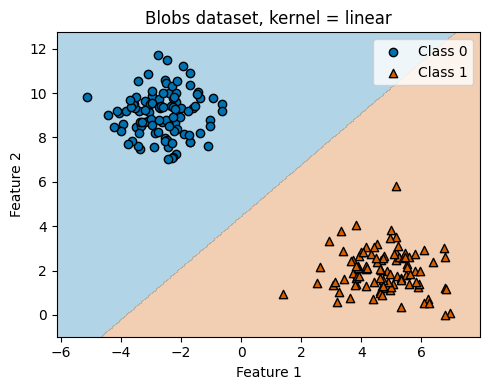

In [4]:
# Generate linearly separable blobs
X_blobs, y_blobs = make_blobs(
    n_samples=200,
    centers=2,
    random_state=RANDOM_STATE,
    cluster_std=1.0,
)

# Train and plot linear SVM
clf_linear_blobs, acc_linear_blobs = train_and_evaluate_svm(
    X_blobs,
    y_blobs,
    kernel="linear",
    title_prefix="Blobs dataset,"
)


### Interpretation: linear kernel on blobs

On the blobs dataset, the two classes form compact clusters that are almost
linearly separable in the original feature space.The SVM with a
linear kernel finds a straight decision boundary that cleanly separates the blue
and orange points, achieving a test accuracy of 1.00.

This illustrates the core idea of a linear SVM: it searches for the hyperplane
that maximises the margin between the closest points of each class (the support
vectors). When the data are well separated by a line, a linear
kernel is both simple and highly effective, and using more complex kernels is
unnecessary.


Section 2 – Moons dataset with different kernels

## 2. Non-linear moons dataset

Next we use the `make_moons` dataset, which forms two interleaving half-moon
shapes. This dataset is **not** linearly separable, so a straight-line
boundary will struggle. We will compare linear, polynomial, and RBF kernels.


In [5]:
# Generate moons dataset
X_moons, y_moons = make_moons(
    n_samples=200,
    noise=0.25,
    random_state=RANDOM_STATE,
)


linear kernel on moons

Moons dataset, kernel='linear', degree=3, gamma=scale, C=1.0
Test accuracy: 0.833


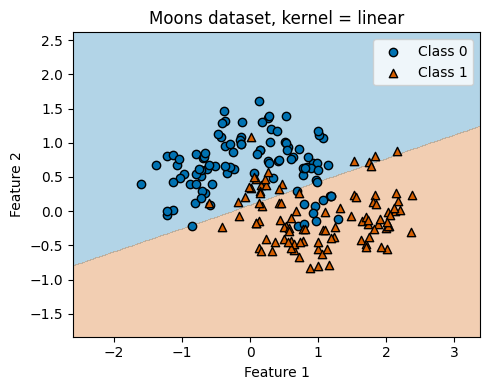

In [6]:
clf_linear_moons, acc_linear_moons = train_and_evaluate_svm(
    X_moons,
    y_moons,
    kernel="linear",
    title_prefix="Moons dataset,"
)


polynomial kernel on moons

Moons dataset, kernel='poly', degree=3, gamma=scale, C=1.0
Test accuracy: 0.933


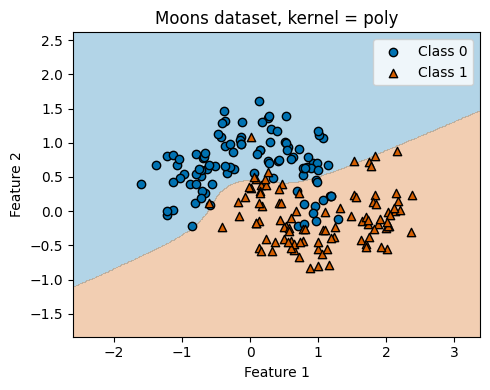

In [7]:
clf_poly_moons, acc_poly_moons = train_and_evaluate_svm(
    X_moons,
    y_moons,
    kernel="poly",
    degree=3,
    gamma="scale",
    C=1.0,
    title_prefix="Moons dataset,"
)


RBF kernel on moons

Moons dataset, kernel='rbf', degree=3, gamma=scale, C=1.0
Test accuracy: 0.933


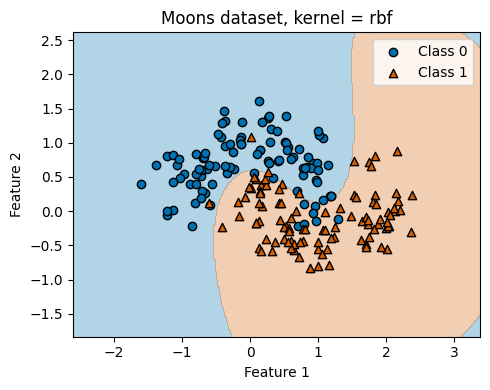

In [8]:
clf_rbf_moons, acc_rbf_moons = train_and_evaluate_svm(
    X_moons,
    y_moons,
    kernel="rbf",
    gamma="scale",
    C=1.0,
    title_prefix="Moons dataset,"
)


### Interpretation: kernels on the moons dataset

The moons dataset forms two interleaving half-moon shapes and is not linearly
separable in the original feature space. With a **linear**
kernel, the SVM can only draw a straight decision boundary, so several points
from each class are misclassified and the test accuracy is lower (around 0.83
in this run).

When we switch to a **polynomial** kernel of degree 3, the boundary becomes
curved and can follow the arc of the moons more closely. This reduces
classification errors and improves the test accuracy to about 0.93.

The **RBF** kernel goes further by allowing a flexible, smoothly curved
boundary that wraps around clusters of points based on local similarity.

On this dataset it achieves similar accuracy to the polynomial kernel (around
0.93), and visually its boundary adapts well to the two moon shapes.

This experiment shows that for non-linear patterns, non-linear kernels such as
polynomial and RBF can capture complex decision boundaries that a linear kernel
cannot.


Section 3 – Circles dataset with different kernels

## 3. Concentric circles dataset

We now use `make_circles`, which creates two concentric circles. This
is another classic non-linear pattern: no straight line can separate the inner
and outer circle. Again, we compare linear, polynomial, and RBF kernels.


In [9]:
# Generate circles dataset
X_circles, y_circles = make_circles(
    n_samples=200,
    factor=0.5,
    noise=0.1,
    random_state=RANDOM_STATE,
)


linear kernel on circles

Circles dataset, kernel='linear', degree=3, gamma=scale, C=1.0
Test accuracy: 0.467


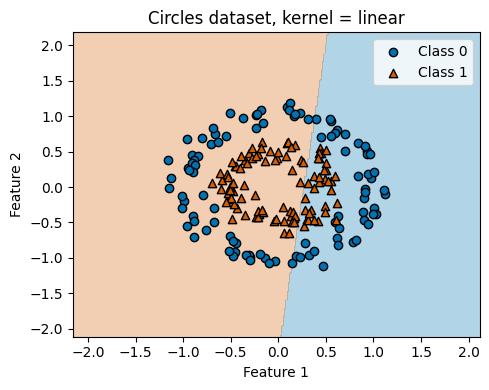

In [10]:
clf_linear_circles, acc_linear_circles = train_and_evaluate_svm(
    X_circles,
    y_circles,
    kernel="linear",
    title_prefix="Circles dataset,"
)


Circles dataset, kernel='poly', degree=3, gamma=scale, C=1.0
Test accuracy: 0.583


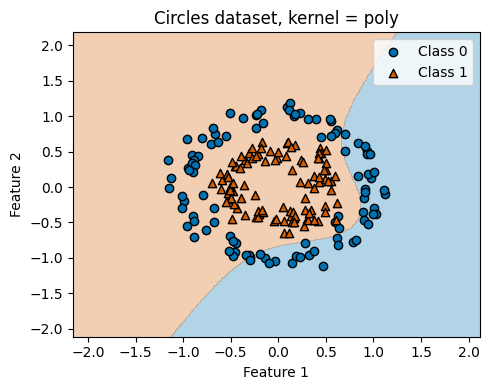

In [11]:
clf_poly_circles, acc_poly_circles = train_and_evaluate_svm(
    X_circles,
    y_circles,
    kernel="poly",
    degree=3,
    gamma="scale",
    C=1.0,
    title_prefix="Circles dataset,"
)


Circles dataset, kernel='rbf', degree=3, gamma=scale, C=1.0
Test accuracy: 0.983


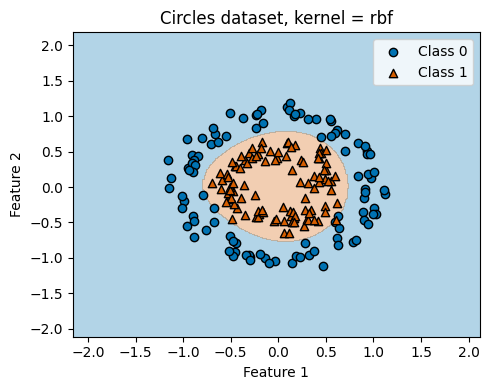

In [12]:
clf_rbf_circles, acc_rbf_circles = train_and_evaluate_svm(
    X_circles,
    y_circles,
    kernel="rbf",
    gamma="scale",
    C=1.0,
    title_prefix="Circles dataset,"
)


### Interpretation: kernels on the circles dataset

The circles dataset consists of two concentric rings: one inner circle and one
outer circle. No straight line can separate these classes, so we
expect a linear kernel to perform poorly. Indeed, the **linear** SVM produces a
vertical decision boundary that cuts through both circles, leading to many
misclassified points and a low test accuracy (around 0.47).

The **polynomial** kernel of degree 3 can bend the boundary, but in this
configuration it still cannot form a clean closed curve around the inner
circle. The decision region is warped but remains roughly
half-plane shaped, so the test accuracy improves only slightly (around 0.58).

With the **RBF** kernel, the SVM can create a circular decision boundary that
wraps tightly around the inner ring of points. This matches the
true structure of the data much better and yields a high test accuracy (about
0.98 in this run). The circles example highlights how RBF kernels are well
suited to problems where classes form compact, non-linear clusters.


Summary table of accuracies

In [13]:
import pandas as pd

results = pd.DataFrame({
    "Dataset": [
        "Blobs", "Moons", "Moons", "Moons",
        "Circles", "Circles", "Circles"
    ],
    "Kernel": [
        "linear",
        "linear", "poly (deg=3)", "rbf",
        "linear", "poly (deg=3)", "rbf",
    ],
    "Accuracy": [
        acc_linear_blobs,
        acc_linear_moons, acc_poly_moons, acc_rbf_moons,
        acc_linear_circles, acc_poly_circles, acc_rbf_circles,
    ],
})

results


,Dataset,Kernel,Accuracy
0,Blobs,linear,1.000000
1,Moons,linear,0.833333
2,Moons,poly (deg=3),0.933333
3,Moons,rbf,0.933333
4,Circles,linear,0.466667
5,Circles,poly (deg=3),0.583333
6,Circles,rbf,0.983333


### Interpreting the accuracy table

On the **blobs** dataset, the linear kernel reaches perfect accuracy. The two
classes are almost linearly separable, so a straight decision boundary is
sufficient and there is no benefit to using more complex kernels.

For the **moons** dataset, the linear kernel achieves about 0.83 accuracy,
while both polynomial (degree 3) and RBF kernels reach around 0.93.
This shows that curved decision boundaries capture the interleaving moon
shapes better than a straight line.

On the **circles** dataset, the linear kernel performs poorly (≈0.47) and the
polynomial kernel only slightly better (≈0.58), because neither can form an
appropriate closed curve around the inner circle. The RBF
kernel, however, achieves very high accuracy (≈0.98) by learning a circular
boundary that matches the structure of the data.

Overall, the results illustrate a key lesson: choose a **linear** kernel when
the classes are roughly linearly separable, but prefer **non-linear** kernels,
especially RBF, when the data exhibit curved or nested patterns.

## 5. Practical and ethical considerations

### Practical tips for choosing a kernel

In practice, a **linear kernel** is a good choice when the classes are roughly
linearly separable or when the number of features is very large (for example,
text data with many word features). Linear SVMs are simpler,
faster to train, and less prone to overfitting when the boundary does not need
to be highly curved.

When the data show clear non-linear structure, such as interleaving clusters or
nested shapes, a **non-linear kernel** is more appropriate. The
RBF kernel is often a strong default because it can model smooth, flexible
boundaries and has only two main hyperparameters (`C` and `gamma`) that control
the trade-off between margin size and boundary complexity.

**Polynomial** kernels can be useful when interactions between features are
naturally polynomial (e.g. quadratic effects), but they can be harder to tune
because the degree, `C`, and `gamma` all influence model complexity.
In practice, it is common to start with linear and RBF kernels, then try
polynomial kernels if there is a clear motivation.

### Overfitting, generalisation, and ethics

Using an overly flexible kernel with poorly chosen hyperparameters can lead to
**overfitting**, where the model fits noise in the training data instead of the
underlying pattern. An overfitted SVM may achieve very high
training accuracy but perform poorly on new data, which is dangerous in
applications such as medical diagnosis, credit scoring, or hiring decisions.

Because SVMs are often applied in settings that affect people, it is important
to evaluate models not only on accuracy but also on stability and fairness.


For example, a model that is highly sensitive to small changes in the data may
behave unpredictably when the underlying population shifts. Responsible model
development involves using validation sets, cross-validation, and, where
possible, fairness and robustness checks before deploying an SVM in practice.
